# Laborator 2 - Simulări în Python

În acest notebook rezolvăm trei exerciţii care folosesc generarea de numere aleatoare:

1. Alegerea unui eşantion aleator fără repetiţie dintr-o listă (fişier `.csv`)
2. Simularea unui joc cu monedă şi zar
3. Simularea timpilor de servire la o frizerie

In [1]:
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# Seed pentru reproducibilitate
np.random.seed(12)
random.seed(12)

## Exerciţiul 1: Eşantion aleator fără repetiţie

**Cerinţă:** un program care citeşte un fişier `.csv` cu o listă şi returnează un număr dat de elemente din listă, **fără repetiţie**. Îl aplicăm pe lista studenţilor din grupă care nu au prezentat încă tema.

Folosim `random.sample`, care alege elemente distincte din listă.

In [2]:
def citeste_lista(cale):
    # citim toate numele din fisierul csv (sarim peste antet)
    with open(cale, newline="", encoding="utf-8") as f:
        cititor = csv.reader(f)
        next(cititor)  # prima linie e antetul
        return [rand[0] for rand in cititor if rand]

def alege_random(lista, k):
    # random.sample alege k elemente DIFERITE (fara repetitie)
    if k > len(lista):
        raise ValueError("k nu poate fi mai mare decat lungimea listei")
    return random.sample(lista, k)

In [3]:
studenti = citeste_lista("studenti.csv")
print("Numar de studenti care nu au prezentat inca:", len(studenti))

k = 3  # cati studenti alegem
alesi = alege_random(studenti, k)
print("Studentii alesi sa prezinte tema:")
for s in alesi:
    print(" -", s)

Numar de studenti care nu au prezentat inca: 8
Studentii alesi sa prezinte tema:
 - Radu Alexandru
 - Georgescu Elena
 - Dumitru Radu


## Exerciţiul 2: Jocul cu moneda şi zarul

La fiecare pas se aruncă moneda:
- **stemă** (probabilitate `p`): al doilea jucător aruncă zarul şi îi dă primului `z - 3` dolari. Jocul se încheie.
- **ban**: primul jucător îi dă celui de-al doilea 0.5 $. Se reia pasul.

### a) Distribuţia lui N

Pasurile sunt independente, iar jocul se opreşte la prima stemă. Deci numărul de paşi **N** urmează o **distribuţie geometrică** cu parametrul `p = 1/2`:

$$P(N = n) = \left(\tfrac12\right)^n, \quad n = 1, 2, 3, \dots$$

Suma pe care al doilea jucător o plăteşte primului este

$$S = (z - 3) - 0.5\,(N - 1)$$

(se scad 0.5 $ pentru fiecare ban, adică de $N-1$ ori).

### b) Simularea unui joc

In [4]:
def joaca_un_joc(p_stema=0.5):
    # returneaza (N, S) pentru un singur joc
    n = 0
    s = 0.0
    while True:
        n += 1
        if np.random.rand() < p_stema:
            # a picat stema: al doilea arunca zarul si plateste z - 3
            z = np.random.randint(1, 7)
            s += z - 3
            break
        else:
            # a picat ban: primul jucator ii da 0.5$ celui de-al doilea
            s -= 0.5
    return n, s

def simuleaza(nr_jocuri, p_stema=0.5):
    rezultate = [joaca_un_joc(p_stema) for _ in range(nr_jocuri)]
    N = np.array([r[0] for r in rezultate])
    S = np.array([r[1] for r in rezultate])
    return N, S

n, s = joaca_un_joc()
print(f"Un joc: N = {n}, S = {s}")

Un joc: N = 1, S = 3.0


### c) Media lui S şi histograma (p = 0.5)

Simulăm 100000 de jocuri şi estimăm media. Teoretic, $E[S] = E[z-3] - 0.5\,E[N-1] = 0.5 - 0.5\cdot\frac{1-p}{p}$, deci pentru $p = 0.5$ obţinem $0$.

Media lui S ~ 0.002  (teoretic: 0)
Media lui N ~ 2.004  (teoretic: 2)


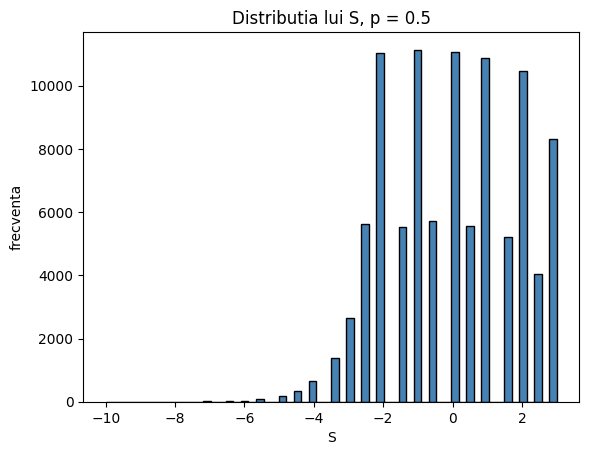

In [5]:
N, S = simuleaza(100000, 0.5)
print(f"Media lui S ~ {S.mean():.3f}  (teoretic: 0)")
print(f"Media lui N ~ {N.mean():.3f}  (teoretic: 2)")

plt.hist(S, bins=60, color="steelblue", edgecolor="black")
plt.title("Distributia lui S, p = 0.5")
plt.xlabel("S")
plt.ylabel("frecventa")
plt.show()

### d) Moneda măsluită

Refacem simularea pentru `p = 0.3` şi `p = 0.7`.

p = 0.3: media lui S ~ -0.681 (teoretic: -0.667)


p = 0.7: media lui S ~ 0.286 (teoretic: 0.286)


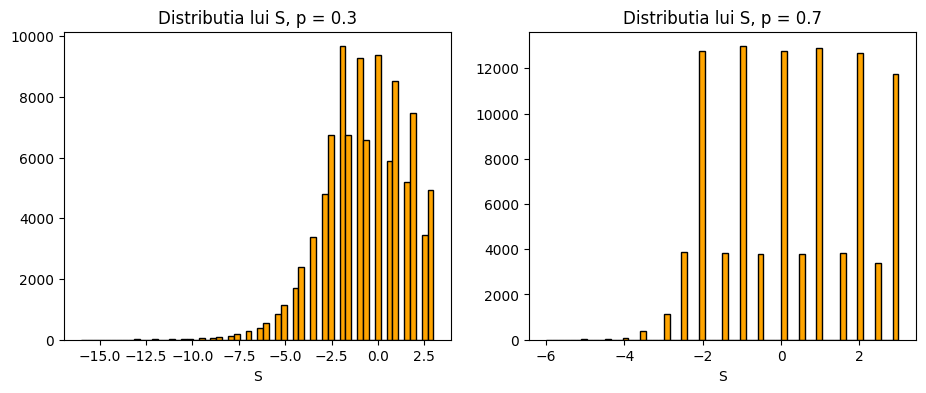

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, p in zip(axs, [0.3, 0.7]):
    N, S = simuleaza(100000, p)
    teoretic = 0.5 - 0.5 * (1 - p) / p
    print(f"p = {p}: media lui S ~ {S.mean():.3f} (teoretic: {teoretic:.3f})")
    ax.hist(S, bins=60, color="orange", edgecolor="black")
    ax.set_title(f"Distributia lui S, p = {p}")
    ax.set_xlabel("S")
plt.show()

**Interpretare:**
- `p = 0.5`: $E[S] = 0$, jocul este corect.
- `p = 0.3`: $E[S] \approx -0.67$. Stema pică rar, se strâng mulţi bani de la ban, deci primul jucător câştigă în medie.
- `p = 0.7`: $E[S] \approx +0.29$. Jocul se termină repede, iar al doilea jucător pierde în medie.

## Exerciţiul 3: Frizeria

Trei frizeri tund cu vitezele $\lambda_1 = 3$, $\lambda_2 = 6$, $\lambda_3 = 4$ clienţi pe oră. Timpul de servire al fiecăruia este $Exp(\lambda_i)$.

**De ce probabilităţile sunt 3/13, 6/13, 4/13?** Un frizer mai rapid termină mai repede şi preia mai mulţi clienţi, deci probabilitatea de a prelua un client este proporţională cu viteza lui. Cum $3 + 6 + 4 = 13$, probabilitatea frizerului $i$ este $\lambda_i / 13$.

Generăm 10000 de valori pentru X (timpul de servire al unui client): alegem frizerul cu aceste probabilităţi, apoi generăm timpul din exponenţiala lui.

In [7]:
n = 10000
lambde = np.array([3, 6, 4])     # clienti / ora
probe = lambde / lambde.sum()    # 3/13, 6/13, 4/13

frizer = np.random.choice(3, size=n, p=probe)
X = np.random.exponential(scale=1 / lambde[frizer])

print(f"Media lui X ~ {X.mean():.4f} ore (teoretic 3/13 = {3/13:.4f})")
print(f"Deviatia standard ~ {X.std():.4f} ore (teoretic ~ 0.2492)")

Media lui X ~ 0.2357 ore (teoretic 3/13 = 0.2308)
Deviatia standard ~ 0.2530 ore (teoretic ~ 0.2492)


Teoretic: $E[X] = \sum p_i/\lambda_i = 3/13 \approx 0.2308$ ore, $E[X^2] = \sum p_i \cdot 2/\lambda_i^2 = 1.5/13$, deci $\sigma \approx 0.249$.

Densitatea aproximativă a lui X (X e continuă, deci folosim `plot_kde` din ArviZ):

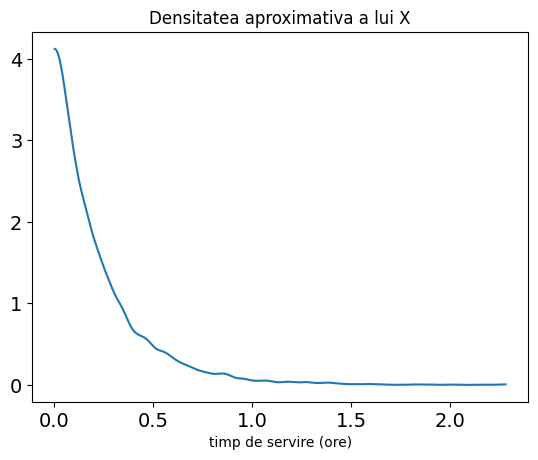

In [8]:
az.plot_kde(X)
plt.title("Densitatea aproximativa a lui X")
plt.xlabel("timp de servire (ore)")
plt.show()